#  Predicción Inteligente de la Copa Mundial FIFA 2026 mediante Machine Learning

---

## Introducción

La predicción de eventos deportivos representa uno de los desafíos más interesantes dentro del campo de la Ciencia de Datos, debido a la gran cantidad de variables 
que influyen en el rendimiento de los equipos y a la naturaleza impredecible del deporte.

En este proyecto se desarrollará un sistema inteligente capaz de estimar las probabilidades de victoria de las selecciones participantes en la Copa Mundial de la 
FIFA 2026 utilizando técnicas de Machine Learning, estadística y simulación Monte Carlo.

Para ello se integrarán dos fuentes principales de información:

- Un conjunto histórico de más de un siglo de partidos internacionales.
- Un conjunto de datos actualizado con el estado real del Mundial 2026.

El objetivo es construir un modelo capaz de analizar el rendimiento histórico de cada selección, incorporar su desempeño actual durante el torneo y generar predicciones 
probabilísticas sobre los partidos restantes y el posible campeón del campeonato.

# Objetivo General

Desarrollar un modelo predictivo basado en técnicas de Machine Learning capaz de estimar probabilidades de victoria entre selecciones nacionales y simular el desarrollo
 completo del Mundial FIFA 2026 utilizando información histórica y datos actualizados del torneo.

# Objetivos Específicos

- Integrar múltiples fuentes de datos.

- Limpiar y normalizar la información.

- Construir variables representativas del rendimiento de cada selección.

- Calcular indicadores históricos y actuales.

- Preparar un dataset óptimo para Machine Learning.

- Entrenar modelos predictivos.

- Simular miles de escenarios del Mundial.

- Desarrollar una aplicación interactiva para visualizar las predicciones.

# 🏗 Arquitectura del Proyecto

```text
          Dataset Histórico
               │
               │
               ▼
        Limpieza de Datos
               │
               ▼
     Feature Engineering
               │
               ▼
      Dataset Procesado
               │
               ▼
      Machine Learning
               │
      ┌────────┴────────┐
      ▼                 ▼
Regresión Poisson   XGBoost
      │                 │
      └────────┬────────┘
               ▼
      Simulación Monte Carlo
               ▼
          Dashboard Streamlit

In [35]:
#  Importación de Librerías

#En esta sección se importan todas las librerías necesarias para el desarrollo del proyecto.

In [36]:
# PROYECTO:
# Predicción Inteligente del Mundial FIFA 2026



# Autor:
# Dariel Peña Vásquez

# Fecha:
# Julio 2026

# LIBRERÍAS PARA MANEJO DE DATOS

import pandas as pd
import numpy as np


# VISUALIZACIÓN

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# UTILIDADES

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# CONFIGURACIÓN GENERAL

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


# ⚙ Configuración del Proyecto

En esta etapa se definen todas las rutas del proyecto.

Esto permitirá que el notebook funcione correctamente sin importar en qué computadora se ejecute, evitando escribir rutas absolutas y facilitando la reutilización del código.

In [37]:
# CONFIGURACIÓN DE RUTAS DEL PROYECTO

ROOT_DIR = Path.cwd().parent

DATA_RAW = ROOT_DIR / "data" / "raw"
DATA_PROCESSED = ROOT_DIR / "data" / "processed"

MODELS = ROOT_DIR / "models"

OUTPUTS = ROOT_DIR / "outputs"

print(f"Proyecto: {ROOT_DIR}")
print(f"Datos RAW: {DATA_RAW}")
print(f"Datos Procesados: {DATA_PROCESSED}")

Proyecto: c:\Users\darie\Downloads\PROYECTO_FIFA2026
Datos RAW: c:\Users\darie\Downloads\PROYECTO_FIFA2026\data\raw
Datos Procesados: c:\Users\darie\Downloads\PROYECTO_FIFA2026\data\processed


# Carga de los datos

En esta etapa se cargan las diferentes fuentes de datos que utilizaremos durante el proyecto.

El objetivo es validar que todos los archivos estén disponibles, revisar su estructura y confirmar que la información pueda ser utilizada en las siguientes etapas del análisis.

Trabajaremos con dos tipos de información:

- Datos históricos de partidos internacionales.
- Datos actualizados del Mundial 2026.

In [38]:
results = pd.read_csv(DATA_RAW / "results.csv")

goalscorers = pd.read_csv(DATA_RAW / "goalscorers.csv")

shootouts = pd.read_csv(DATA_RAW / "shootouts.csv")

former_names = pd.read_csv(DATA_RAW / "former_names.csv")

world_cup = pd.read_excel(DATA_RAW / "Dataset_Mundial_2026_Actualizado.xlsx")

print("Todos los datasets fueron cargados correctamente.")

Todos los datasets fueron cargados correctamente.


In [39]:
datasets = {
    "Resultados": results,
    "Goleadores": goalscorers,
    "Penales": shootouts,
    "Nombres Historicos": former_names,
    "Mundial 2026": world_cup
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Filas": [df.shape[0] for df in datasets.values()],
    "Columnas": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Filas,Columnas
0,Resultados,49502,9
1,Goleadores,47867,8
2,Penales,681,5
3,Nombres Historicos,36,4
4,Mundial 2026,48,12


Antes de transformar cualquier dato es recomendable revisar visualmente el contenido de cada archivo.

Esto ayuda a identificar nombres de columnas, tipos de variables y posibles inconsistencias desde el inicio.

In [40]:
def preview_dataset(name, dataframe, rows=5):
    print(f"\n{name}")
    display(dataframe.head(rows))

In [41]:
preview_dataset("Resultados", results)

preview_dataset("Goleadores", goalscorers)

preview_dataset("Penales", shootouts)

preview_dataset("Nombres Historicos", former_names)

preview_dataset("Mundial 2026", world_cup)


Resultados


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.00,0.00,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.00,2.00,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.00,1.00,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.00,2.00,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.00,0.00,Friendly,Glasgow,Scotland,False



Goleadores


,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.00,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.00,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.00,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.00,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.00,False,False



Penales


,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN



Nombres Historicos


,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01



Mundial 2026


,País,Grupo,Partidos Jugados,Victorias,Empates,Derrotas,Goles a Favor,Goles en Contra,Diferencia de Goles,Puntos,Estado / Fase Actual,Notas Clave
0,México,A,4,3,0,1,7,2,5,9,Eliminado en Octavos de Final,Cayeron en el 4to partido
1,Sudáfrica,A,4,1,1,2,2,5,-3,4,Eliminado en Ronda de 32,NaN
2,Corea del Sur,A,3,1,0,2,2,3,-1,3,Eliminado en Fase de Grupos,NaN
3,República Checa,A,3,0,1,2,2,6,-4,1,Eliminado en Fase de Grupos,NaN
4,Suiza,B,5,3,1,1,9,5,4,10,Clasificado a Cuartos de Final,Avanza sólido


## Estructura de los datos

Ahora revisaremos la estructura de cada dataset.

Nos interesa conocer el tipo de dato de cada columna, la cantidad de registros y si existen valores faltantes antes de iniciar el proceso de limpieza.

In [42]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49502 entries, 0 to 49501
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49502 non-null  object 
 1   home_team   49502 non-null  object 
 2   away_team   49502 non-null  object 
 3   home_score  49495 non-null  float64
 4   away_score  49495 non-null  float64
 5   tournament  49502 non-null  object 
 6   city        49502 non-null  object 
 7   country     49502 non-null  object 
 8   neutral     49502 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [43]:
def dataset_info(name, dataframe):

    info = pd.DataFrame({
        "Columna": dataframe.columns,
        "Tipo": dataframe.dtypes.values,
        "Valores Nulos": dataframe.isna().sum().values,
        "Porcentaje Nulos": (
            dataframe.isna().mean() * 100
        ).round(2).values
    })

    print(f"\n{name}")

    display(info)

In [44]:
dataset_info("Resultados", results)

dataset_info("Goleadores", goalscorers)

dataset_info("Penales", shootouts)

dataset_info("Nombres Historicos", former_names)

dataset_info("Mundial 2026", world_cup)


Resultados


,Columna,Tipo,Valores Nulos,Porcentaje Nulos
0,date,object,0,0.00
1,home_team,object,0,0.00
2,away_team,object,0,0.00
3,home_score,float64,7,0.01
4,away_score,float64,7,0.01
5,tournament,object,0,0.00
6,city,object,0,0.00
7,country,object,0,0.00
8,neutral,bool,0,0.00



Goleadores


,Columna,Tipo,Valores Nulos,Porcentaje Nulos
0,date,object,0,0.00
1,home_team,object,0,0.00
2,away_team,object,0,0.00
3,team,object,0,0.00
4,scorer,object,44,0.09
5,minute,float64,254,0.53
6,own_goal,bool,0,0.00
7,penalty,bool,0,0.00



Penales


,Columna,Tipo,Valores Nulos,Porcentaje Nulos
0,date,object,0,0.00
1,home_team,object,0,0.00
2,away_team,object,0,0.00
3,winner,object,0,0.00
4,first_shooter,object,422,61.97



Nombres Historicos


,Columna,Tipo,Valores Nulos,Porcentaje Nulos
0,current,object,0,0.00
1,former,object,0,0.00
2,start_date,object,0,0.00
3,end_date,object,0,0.00



Mundial 2026


,Columna,Tipo,Valores Nulos,Porcentaje Nulos
0,País,object,0,0.00
1,Grupo,object,0,0.00
2,Partidos Jugados,int64,0,0.00
3,Victorias,int64,0,0.00
4,Empates,int64,0,0.00
5,Derrotas,int64,0,0.00
6,Goles a Favor,int64,0,0.00
7,Goles en Contra,int64,0,0.00
8,Diferencia de Goles,int64,0,0.00
9,Puntos,int64,0,0.00


## Conclusiones de la exploración inicial

La revisión de la estructura de los datasets muestra que la calidad general de la información es buena.

Los archivos históricos presentan muy pocos valores faltantes y, en principio, no representan un riesgo para el análisis.

Los porcentajes altos de valores nulos encontrados en algunas columnas corresponden a variables descriptivas que no serán utilizadas durante el entrenamiento del modelo, por lo que no afectan el objetivo principal del proyecto.

Con esta primera validación podemos continuar con un diagnóstico más profundo de la calidad de los datos.

Existen registros duplicados?

# Diagnóstico de calidad de los datos

Antes de comenzar el proceso de limpieza es importante identificar posibles problemas que puedan afectar el entrenamiento del modelo.

En esta etapa evaluaremos aspectos como registros duplicados, valores inconsistentes y diferencias en los nombres de las selecciones.

In [45]:
for name, df in datasets.items():

    duplicated = df.duplicated().sum()

    print(f"{name}: {duplicated} registros duplicados")

Resultados: 0 registros duplicados
Goleadores: 79 registros duplicados
Penales: 0 registros duplicados
Nombres Historicos: 0 registros duplicados
Mundial 2026: 0 registros duplicados


## Validación del formato de fechas

Los modelos utilizarán información histórica de cada selección.

Por esta razón es importante confirmar que las fechas puedan convertirse correctamente al formato de fecha de Python.

In [46]:
#¿Existen fechas inválidas?
results["date"] = pd.to_datetime(results["date"])

goalscorers["date"] = pd.to_datetime(goalscorers["date"])

shootouts["date"] = pd.to_datetime(shootouts["date"])

In [47]:
print(results["date"].min())
print(results["date"].max())

1872-11-30 00:00:00
2026-07-09 00:00:00


In [48]:
#¿Cuántos países existen realmente?

historical_teams = sorted(
    set(results["home_team"]).union(results["away_team"])
)

print(f"Cantidad de selecciones: {len(historical_teams)}")

Cantidad de selecciones: 336


In [49]:
pd.DataFrame(
    historical_teams,
    columns=["Pais"]
).head(30)

,Pais
0,Abkhazia
1,Afghanistan
2,Albania
3,Alderney
4,Algeria
5,Ambazonia
6,American Samoa
7,Andalusia
8,Andorra
9,Angola


# Analisis de las selecciones

El dataset historico incluye partidos disputados durante mas de un siglo. Debido a esto, es posible encontrar selecciones nacionales, equipos regionales y representativos que nunca han participado en competiciones oficiales de la FIFA.

Antes de aplicar cualquier filtro es importante conocer cuantas selecciones diferentes existen y cuales forman parte del historial.

In [50]:
print(f"Cantidad de selecciones unicas: {len(historical_teams)}")

Cantidad de selecciones unicas: 336


In [51]:
historical_teams_df = pd.DataFrame(
    historical_teams,
    columns=["Pais"]
)

historical_teams_df

,Pais
0,Abkhazia
1,Afghanistan
2,Albania
3,Alderney
4,Algeria
...,...
331,Yugoslavia
332,Zambia
333,Zanzibar
334,Zimbabwe


## Validacion de equipos del Mundial

El siguiente paso consiste en verificar que todas las selecciones participantes en el Mundial 2026 existan dentro del dataset historico.

Si algun pais no aparece, el modelo no tendra informacion suficiente para generar sus variables historicas.

In [52]:
world_cup_teams = sorted(world_cup["País"].unique())

missing_teams = [
    team
    for team in world_cup_teams
    if team not in historical_teams
]

print(f"Equipos del Mundial: {len(world_cup_teams)}")

print(f"Equipos encontrados: {len(world_cup_teams)-len(missing_teams)}")

print(f"Equipos faltantes: {len(missing_teams)}")

missing_teams

Equipos del Mundial: 48
Equipos encontrados: 11
Equipos faltantes: 37


['Alemania',
 'Arabia Saudita',
 'Argelia',
 'Bosnia y Herzegovina',
 'Brasil',
 'Bélgica',
 'Cabo Verde',
 'Canadá',
 'Corea del Sur',
 'Costa de Marfil',
 'Croacia',
 'Curazao',
 'Egipto',
 'Escocia',
 'España',
 'Estados Unidos',
 'Francia',
 'Haití',
 'Inglaterra',
 'Irak',
 'Irán',
 'Japón',
 'Jordania',
 'Marruecos',
 'México',
 'Noruega',
 'Nueva Zelanda',
 'Panamá',
 'Países Bajos',
 'RD Congo',
 'República Checa',
 'Sudáfrica',
 'Suecia',
 'Suiza',
 'Turquía',
 'Túnez',
 'Uzbekistán']

## Analisis de torneos

El dataset incluye diferentes tipos de competiciones oficiales y amistosas.

Conocer esta distribucion sera importante para definir si todos los partidos tendran el mismo peso dentro del modelo o si algunas competiciones tendran una mayor influencia.

In [53]:
tournaments = (
    results["tournament"]
    .value_counts()
    .reset_index()
)

tournaments.columns = ["Torneo", "Cantidad de Partidos"]

tournaments

,Torneo,Cantidad de Partidos
0,Friendly,18388
1,FIFA World Cup qualification,8771
2,UEFA Euro qualification,2824
3,African Cup of Nations qualification,2327
4,FIFA World Cup,1061
...,...,...
195,Copa Confraternidad,1
196,ConIFA Challenger Cup,1
197,Benedikt Fontana Cup,1
198,CONIFA World Cup qualification,1


# Analisis exploratorio del dataset historico

Antes de iniciar el proceso de limpieza es importante entender el comportamiento general del conjunto de datos.

En esta etapa se responderan algunas preguntas que nos ayudaran a conocer el alcance del historial disponible y la distribucion de los partidos internacionales.

In [54]:
#¿Cuántos partidos existen?
print(f"Cantidad total de partidos: {len(results):,}")

Cantidad total de partidos: 49,502


In [55]:
#¿Cuántos años cubre?

print(f"Primer partido: {results['date'].min().date()}")

print(f"Ultimo partido: {results['date'].max().date()}")

Primer partido: 1872-11-30
Ultimo partido: 2026-07-09


In [56]:
results["year"] = results["date"].dt.year

In [57]:
results["year"].describe()

count   49502.00
mean     1993.88
std        25.44
min      1872.00
25%      1980.00
50%      2000.00
75%      2013.00
max      2026.00
Name: year, dtype: float64

In [58]:
#¿Cuántos partidos se jugaron por año?

matches_per_year = (
    results
    .groupby("year")
    .size()
    .reset_index(name="Partidos")
)

matches_per_year.head()

,year,Partidos
0,1872,1
1,1873,1
2,1874,1
3,1875,1
4,1876,2


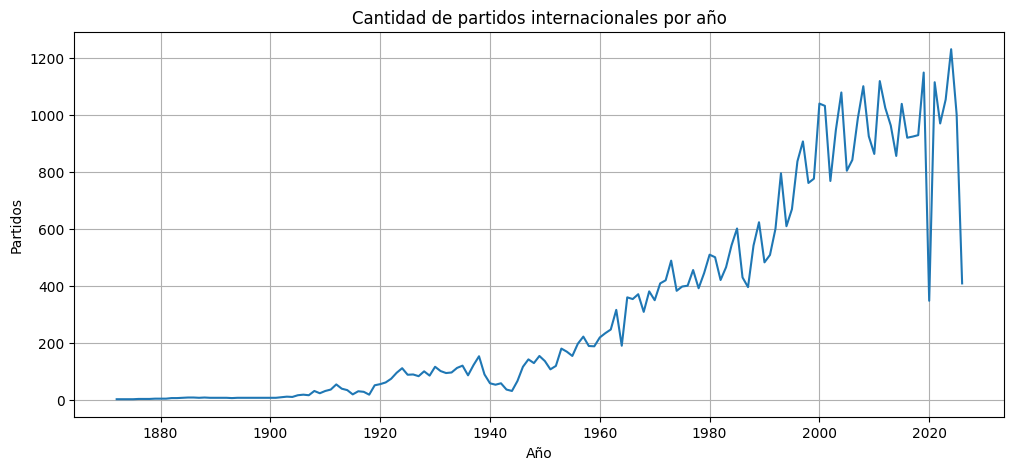

In [147]:
plt.figure(figsize=(12,5))

plt.plot(
    matches_per_year["year"],
    matches_per_year["Partidos"]
)

plt.title("Cantidad de partidos internacionales por año")

plt.xlabel("Año")

plt.ylabel("Partidos")

plt.grid(True)
plt.savefig(r"C:\Users\darie\Downloads\PROYECTO_FIFA2026\outputs\figures\Grafico Cantidad Partidos.png")
plt.show()

In [60]:
home_matches = results["home_team"].value_counts()

away_matches = results["away_team"].value_counts()

total_matches = (
    home_matches.add(
        away_matches,
        fill_value=0
    )
    .sort_values(ascending=False)
)

total_matches.head(20)

Sweden        1105.00
England       1095.00
Argentina     1074.00
Brazil        1064.00
Germany       1035.00
South Korea   1010.00
Mexico        1008.00
Hungary       1006.00
Uruguay        973.00
France         941.00
Italy          893.00
Poland         892.00
Switzerland    889.00
Netherlands    883.00
Norway         877.00
Denmark        874.00
Thailand       865.00
Austria        864.00
Belgium        858.00
Scotland       854.00
Name: count, dtype: float64

In [61]:
total_matches = (
    total_matches
    .reset_index()
)

total_matches.columns = [
    "Pais",
    "Partidos"
]

total_matches.head(20)

,Pais,Partidos
0,Sweden,1105.00
1,England,1095.00
2,Argentina,1074.00
3,Brazil,1064.00
4,Germany,1035.00
5,South Korea,1010.00
6,Mexico,1008.00
7,Hungary,1006.00
8,Uruguay,973.00
9,France,941.00


In [62]:
country_mapping = {
    "Germany": "Alemania",
    "Spain": "España",
    "Brazil": "Brasil",
    "England": "Inglaterra",
}

# Preparacion del dataset historico

A partir de esta etapa comenzaremos el proceso de preparacion de los datos.

Con el fin de conservar la informacion original, todas las transformaciones se realizaran sobre una copia del dataset historico.

Esto permite mantener la trazabilidad del proyecto y facilita repetir el proceso de preparacion cuando sea necesario.

In [63]:
results_clean = results.copy()

print("Se creo una copia del dataset historico.")

Se creo una copia del dataset historico.


## Validacion de registros duplicados

Uno de los primeros controles de calidad consiste en verificar si existen partidos registrados mas de una vez.

La presencia de registros duplicados puede afectar el entrenamiento del modelo y generar sesgos en las variables historicas.

In [64]:
duplicate_matches = results_clean.duplicated(
    subset=[
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "tournament"
    ]
)

duplicate_matches.sum()

np.int64(1)

In [65]:
results_clean.loc[duplicate_matches]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
49361,2026-06-06,Gibraltar,Cayman Islands,4.00,1.00,Friendly,Europa Point,Gibraltar,False,2026


## Validacion de resultados

Antes de continuar verificaremos que los marcadores registrados sean consistentes y que no existan valores imposibles dentro del historial.

In [66]:
invalid_scores = results_clean[
    (results_clean["home_score"] < 0) |
    (results_clean["away_score"] < 0)
]

invalid_scores

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year


# Reglas de negocio

Durante el proceso de preparacion se definieron las siguientes reglas:

- Cada seleccion debe tener un unico nombre oficial.
- No se utilizaran marcadores invalidos.
- Los partidos duplicados seran eliminados.
- El dataset historico no sera modificado directamente.
- Todas las transformaciones se realizaran sobre una copia del conjunto original.
- El dataset del Mundial 2026 se utilizara como informacion complementaria y no para entrenar el modelo.

# Construccion de estadisticas por seleccion

El modelo no utilizara directamente cada partido historico.

En su lugar se construira un conjunto de indicadores que resuman el rendimiento historico de cada seleccion.

Estas variables serviran como punto de partida para calcular la fortaleza de cada equipo antes de incorporar nuevas caracteristicas.

In [67]:
teams = sorted(
    pd.unique(
        pd.concat([
            results_clean["home_team"],
            results_clean["away_team"]
        ])
    )
)

len(teams)

336

In [68]:
team_stats = pd.DataFrame({
    "Pais": teams
})

team_stats.head()

,Pais
0,Abkhazia
1,Afghanistan
2,Albania
3,Alderney
4,Algeria


In [69]:
def total_matches(team):

    home = (
        results_clean["home_team"] == team
    ).sum()

    away = (
        results_clean["away_team"] == team
    ).sum()

    return home + away

In [70]:
team_stats["Partidos"] = (
    team_stats["Pais"]
    .apply(total_matches)
)

team_stats.head()

,Pais,Partidos
0,Abkhazia,33
1,Afghanistan,147
2,Albania,398
3,Alderney,135
4,Algeria,621


In [71]:
team_stats["Victorias"] = ...

team_stats["Empates"] = ...

team_stats["Derrotas"] = ...

team_stats["GF"] = ...

team_stats["GC"] = ...

team_stats["Win Rate"] = ...

team_stats["Promedio GF"] = ...

In [72]:
def calculate_team_statistics(team):
    return {
        "Partidos": ...,
        "Victorias": ...,
        "Empates": ...,
        "Derrotas": ...,
        "GF": ...,
        "GC": ...,
        "Diferencia": ...,
        "WinRate": ...,
        "PromedioGF": ...,
        "PromedioGC": ...
    }

In [73]:
team_stats = pd.DataFrame(
    [calculate_team_statistics(team) for team in teams]
)

# Normalizacion de nombres de paises

El dataset historico se encuentra en ingles, mientras que el dataset del Mundial 2026 utiliza nombres en español.

Para poder integrar ambas fuentes de informacion es necesario unificar los nombres de las selecciones.

In [74]:
country_mapping = {
    "Argentina": "Argentina",
    "Germany": "Alemania",
    "Algeria": "Argelia",
    "Australia": "Australia",
    "Austria": "Austria",
    "Belgium": "Bélgica",
    "Bosnia and Herzegovina": "Bosnia y Herzegovina",
    "Brazil": "Brasil",
    "Canada": "Canadá",
    "Cape Verde": "Cabo Verde",
    "Croatia": "Croacia",
    "Curacao": "Curazao",
    "Czech Republic": "República Checa",
    "DR Congo": "RD del Congo",
    "Ecuador": "Ecuador",
    "Egypt": "Egipto",
    "England": "Inglaterra",
    "France": "Francia",
    "Germany": "Alemania",
    "Ghana": "Ghana",
    "Haiti": "Haití",
    "Iran": "Irán",
    "Iraq": "Irak",
    "Japan": "Japón",
    "Jordan": "Jordania",
    "Mexico": "México",
    "Morocco": "Marruecos",
    "Netherlands": "Países Bajos",
    "New Zealand": "Nueva Zelanda",
    "Norway": "Noruega",
    "Panama": "Panamá",
    "Paraguay": "Paraguay",
    "Portugal": "Portugal",
    "Qatar": "Catar",
    "Saudi Arabia": "Arabia Saudita",
    "Scotland": "Escocia",
    "Senegal": "Senegal",
    "South Africa": "Sudáfrica",
    "South Korea": "Corea del Sur",
    "Spain": "España",
    "Sweden": "Suecia",
    "Switzerland": "Suiza",
    "Tunisia": "Túnez",
    "Turkey": "Turquía",
    "United States": "Estados Unidos",
    "Uruguay": "Uruguay",
    "Uzbekistan": "Uzbekistán"
}

In [75]:
results_clean["home_team"] = (
    results_clean["home_team"]
    .replace(country_mapping)
)

results_clean["away_team"] = (
    results_clean["away_team"]
    .replace(country_mapping)
)

In [77]:
#Validacion

historical_teams = sorted(
    set(results_clean["home_team"])
    .union(results_clean["away_team"])
)

missing_teams = [
    team
    for team in world_cup["País"].unique()
    if team not in historical_teams
]

print(f"Equipos faltantes: {len(missing_teams)}")

missing_teams

Equipos faltantes: 4


['Qatar', 'Costa de Marfil', 'Curazao', 'RD Congo']

# Construcción de las estadísticas históricas por selección

El modelo no utilizará directamente los partidos individuales para realizar las predicciones.

En esta etapa se resumirá el historial de cada selección en un conjunto de indicadores que describen su rendimiento histórico.

Estas variables servirán como base para calcular la fortaleza de cada equipo antes de incorporar información del Mundial 2026.

In [78]:
def calculate_team_statistics(team):

    home_matches = results_clean[results_clean["home_team"] == team]
    away_matches = results_clean[results_clean["away_team"] == team]

    played = len(home_matches) + len(away_matches)

    wins = (
        (home_matches["home_score"] > home_matches["away_score"]).sum()
        +
        (away_matches["away_score"] > away_matches["home_score"]).sum()
    )

    draws = (
        (home_matches["home_score"] == home_matches["away_score"]).sum()
        +
        (away_matches["away_score"] == away_matches["home_score"]).sum()
    )

    losses = played - wins - draws

    goals_for = (
        home_matches["home_score"].sum()
        +
        away_matches["away_score"].sum()
    )

    goals_against = (
        home_matches["away_score"].sum()
        +
        away_matches["home_score"].sum()
    )

    return {

        "Pais": team,

        "Partidos": played,

        "Victorias": wins,

        "Empates": draws,

        "Derrotas": losses,

        "Goles_Favor": goals_for,

        "Goles_Contra": goals_against

    }

In [79]:
teams = sorted(
    pd.unique(
        pd.concat([
            results_clean["home_team"],
            results_clean["away_team"]
        ])
    )
)

team_stats = pd.DataFrame(

    [calculate_team_statistics(team) for team in teams]

)

In [80]:
team_stats.head()

,Pais,Partidos,Victorias,Empates,Derrotas,Goles_Favor,Goles_Contra
0,Abkhazia,33,15,13,5,54.00,26.00
1,Afghanistan,147,36,34,77,142.00,293.00
2,Albania,398,110,84,204,377.00,589.00
3,Alderney,135,5,2,128,73.00,620.00
4,Alemania,1035,601,214,220,2331.00,1203.00


In [82]:
team_stats.tail()

,Pais,Partidos,Victorias,Empates,Derrotas,Goles_Favor,Goles_Contra
331,Yugoslavia,483,223,98,162,942.00,756.00
332,Zambia,793,358,203,232,1234.00,851.00
333,Zanzibar,209,44,41,124,191.00,436.00
334,Zimbabwe,496,190,139,167,660.00,591.00
335,Åland Islands,51,21,8,22,77.00,86.00


## Creación de indicadores históricos

Además de las estadísticas básicas, se calcularán indicadores derivados que describen de una mejor forma el rendimiento histórico de cada selección.

Estas variables tendrán un papel importante durante el entrenamiento del modelo.

In [83]:
team_stats["Diferencia_Goles"] = (
    team_stats["Goles_Favor"]
    -
    team_stats["Goles_Contra"]
)

team_stats["Win_Rate"] = (
    team_stats["Victorias"]
    /
    team_stats["Partidos"]
)

team_stats["Promedio_GF"] = (
    team_stats["Goles_Favor"]
    /
    team_stats["Partidos"]
)

team_stats["Promedio_GC"] = (
    team_stats["Goles_Contra"]
    /
    team_stats["Partidos"]
)

team_stats["Puntos_Historicos"] = (

    team_stats["Victorias"] * 3

    +

    team_stats["Empates"]

)

In [84]:
team_stats.sort_values(
    by="Win_Rate",
    ascending=False
).head(20)

,Pais,Partidos,Victorias,Empates,Derrotas,Goles_Favor,Goles_Contra,Diferencia_Goles,Win_Rate,Promedio_GF,Promedio_GC,Puntos_Historicos
19,Asturias,1,1,0,0,3.00,1.00,2.00,1.00,3.00,1.00,3
284,Surrey,1,1,0,0,3.00,1.00,2.00,1.00,3.00,1.00,3
91,Elba Island,2,2,0,0,9.00,2.00,7.00,1.00,4.50,1.00,6
186,Maule Sur,2,2,0,0,2.00,0.00,2.00,1.00,1.00,0.00,6
158,Kurdistan,5,4,1,0,12.00,2.00,10.00,0.80,2.40,0.40,13
52,Canary Islands,4,3,0,1,11.00,3.00,8.00,0.75,2.75,0.75,9
329,Yorkshire,7,5,1,1,27.00,11.00,16.00,0.71,3.86,1.57,16
73,County of Nice,9,6,1,2,19.00,13.00,6.00,0.67,2.11,1.44,19
234,Quebec,3,2,0,1,24.00,2.00,22.00,0.67,8.00,0.67,6
226,Parishes of Jersey,3,2,0,1,11.00,4.00,7.00,0.67,3.67,1.33,6


# Filtrado de selecciones oficiales

El dataset histórico contiene selecciones nacionales, equipos regionales y representativos que no pertenecen a competiciones oficiales de la FIFA.

Con el objetivo de entrenar un modelo representativo del fútbol internacional moderno, se conservarán únicamente las selecciones nacionales oficiales.

In [85]:
official_teams = set(world_cup["País"])

team_stats["Es_Mundial_2026"] = (
    team_stats["Pais"]
    .isin(official_teams)
)

team_stats.head()

,Pais,Partidos,Victorias,Empates,Derrotas,Goles_Favor,Goles_Contra,Diferencia_Goles,Win_Rate,Promedio_GF,Promedio_GC,Puntos_Historicos,Es_Mundial_2026
0,Abkhazia,33,15,13,5,54.00,26.00,28.00,0.45,1.64,0.79,58,False
1,Afghanistan,147,36,34,77,142.00,293.00,-151.00,0.24,0.97,1.99,142,False
2,Albania,398,110,84,204,377.00,589.00,-212.00,0.28,0.95,1.48,414,False
3,Alderney,135,5,2,128,73.00,620.00,-547.00,0.04,0.54,4.59,17,False
4,Alemania,1035,601,214,220,2331.00,1203.00,1128.00,0.58,2.25,1.16,2017,True


In [86]:
team_stats["Es_Mundial_2026"].value_counts()

Es_Mundial_2026
False    292
True      44
Name: count, dtype: int64

In [87]:
team_stats[
    team_stats["Es_Mundial_2026"]
]

,Pais,Partidos,Victorias,Empates,Derrotas,Goles_Favor,Goles_Contra,Diferencia_Goles,Win_Rate,Promedio_GF,Promedio_GC,Puntos_Historicos,Es_Mundial_2026
4,Alemania,1035,601,214,220,2331.00,1203.00,1128.00,0.58,2.25,1.16,2017,True
12,Arabia Saudita,744,351,172,221,1139.00,782.00,357.00,0.47,1.53,1.05,1225,True
14,Argelia,621,289,163,169,958.00,622.00,336.00,0.47,1.54,1.00,1030,True
15,Argentina,1074,596,257,221,2039.00,1078.00,961.00,0.55,1.90,1.00,2045,True
20,Australia,585,297,125,163,1170.00,622.00,548.00,0.51,2.00,1.06,1016,True
21,Austria,864,368,185,311,1547.00,1324.00,223.00,0.43,1.79,1.53,1289,True
38,Bosnia y Herzegovina,287,105,68,114,393.00,396.00,-3.00,0.37,1.37,1.38,383,True
40,Brasil,1064,675,217,172,2314.00,959.00,1355.00,0.63,2.17,0.90,2242,True
47,Bélgica,858,384,183,291,1559.00,1294.00,265.00,0.45,1.82,1.51,1335,True
48,Cabo Verde,239,89,59,91,262.00,270.00,-8.00,0.37,1.10,1.13,326,True


# Filtrado del histórico

Con el objetivo de entrenar el modelo utilizando un fútbol más representativo del contexto actual, se conservarán únicamente los partidos disputados a partir del año 2000.

Esto reduce el impacto de selecciones históricas, cambios en las reglas del juego y diferencias de contexto competitivo.

In [88]:
results_model = results_clean[results_clean["year"] >= 2000].copy()

print(f"Partidos para entrenamiento: {len(results_model):,}")

Partidos para entrenamiento: 25,440


# Construcción del dataset para Machine Learning

El modelo aprenderá a partir de partidos individuales.

Cada registro representará un encuentro entre dos selecciones e incluirá variables históricas de ambos equipos junto con el resultado final del partido.

In [89]:
team_stats_model = team_stats.copy()

team_stats_model = team_stats_model.rename(columns={
    "Pais": "Team"
})

In [90]:
model_df = results_model.merge(

    team_stats_model,

    left_on="home_team",

    right_on="Team",

    how="left"

)

In [91]:
model_df.shape

(25440, 23)

In [92]:
away_stats = team_stats_model.add_suffix("_Away")

model_df = model_df.merge(

    away_stats,

    left_on="away_team",

    right_on="Team_Away",

    how="left"

)

In [93]:
model_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,Team,Partidos,Victorias,Empates,Derrotas,Goles_Favor,Goles_Contra,Diferencia_Goles,Win_Rate,Promedio_GF,Promedio_GC,Puntos_Historicos,Es_Mundial_2026,Team_Away,Partidos_Away,Victorias_Away,Empates_Away,Derrotas_Away,Goles_Favor_Away,Goles_Contra_Away,Diferencia_Goles_Away,Win_Rate_Away,Promedio_GF_Away,Promedio_GC_Away,Puntos_Historicos_Away,Es_Mundial_2026_Away
0,2000-01-04,Egipto,Togo,2.00,1.00,Friendly,Aswan,Egypt,False,2000,Egipto,761,380,188,193,1231.00,770.00,461.00,0.50,1.62,1.01,1328,True,Togo,447,141,114,192,492.00,620.00,-128.00,0.32,1.10,1.39,537,False
1,2000-01-07,Túnez,Togo,7.00,0.00,Friendly,Tunis,Tunisia,False,2000,Túnez,681,296,189,196,976.00,702.00,274.00,0.43,1.43,1.03,1077,True,Togo,447,141,114,192,492.00,620.00,-128.00,0.32,1.10,1.39,537,False
2,2000-01-08,Trinidad and Tobago,Canadá,0.00,0.00,Friendly,Port of Spain,Trinidad and Tobago,False,2000,Trinidad and Tobago,753,321,164,268,1268.00,1007.00,261.00,0.43,1.68,1.34,1127,False,Canadá,474,181,109,184,617.00,618.00,-1.00,0.38,1.30,1.30,652,True
3,2000-01-09,Burkina Faso,Gabon,1.00,1.00,Friendly,Ouagadougou,Burkina Faso,False,2000,Burkina Faso,464,164,123,177,580.00,617.00,-37.00,0.35,1.25,1.33,615,False,Gabon,405,141,114,150,477.00,484.00,-7.00,0.35,1.18,1.20,537,False
4,2000-01-09,Guatemala,Armenia,1.00,1.00,Friendly,Los Angeles,United States,True,2000,Guatemala,554,199,140,215,774.00,763.00,11.00,0.36,1.40,1.38,737,False,Armenia,272,65,57,150,274.00,499.00,-225.00,0.24,1.01,1.83,252,False


In [94]:
model_df["Resultado"] = np.select(

    [

        model_df["home_score"] > model_df["away_score"],

        model_df["home_score"] == model_df["away_score"]

    ],

    [

        "Local",

        "Empate"

    ],

    default="Visitante"

)

In [95]:
model_df["Resultado"].value_counts()

Resultado
Local        12246
Visitante     7268
Empate        5926
Name: count, dtype: int64

In [96]:
model_df.to_csv(

    DATA_PROCESSED / "dataset_modelo.csv",

    index=False,

    encoding="utf-8-sig"

)

print("Dataset del modelo guardado correctamente.")

Dataset del modelo guardado correctamente.


# Construcción del dataset de entrenamiento

El modelo aprenderá a partir de partidos individuales.

Cada fila representará un encuentro entre dos selecciones y contendrá variables calculadas únicamente con la información disponible hasta ese momento.

Este será el dataset principal utilizado durante el entrenamiento del modelo.

In [104]:
matches = results_model.copy()

matches.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year
24062,2000-01-04,Egipto,Togo,2.00,1.00,Friendly,Aswan,Egypt,False,2000
24063,2000-01-07,Túnez,Togo,7.00,0.00,Friendly,Tunis,Tunisia,False,2000
24064,2000-01-08,Trinidad and Tobago,Canadá,0.00,0.00,Friendly,Port of Spain,Trinidad and Tobago,False,2000
24065,2000-01-09,Burkina Faso,Gabon,1.00,1.00,Friendly,Ouagadougou,Burkina Faso,False,2000
24066,2000-01-09,Guatemala,Armenia,1.00,1.00,Friendly,Los Angeles,United States,True,2000


In [115]:
matches = matches.sort_values("date").reset_index(drop=True)

In [116]:
matches["home_matches"] = np.nan
matches["away_matches"] = np.nan

matches["home_wins"] = np.nan
matches["away_wins"] = np.nan

matches["home_goals"] = np.nan
matches["away_goals"] = np.nan

In [117]:
team_history = {}

In [128]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [129]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.feature_builder import build_match_features

print("Importación correcta")

Importación correcta


In [138]:
from src.feature_builder import build_match_features


In [139]:
model_df = build_match_features(results_model)

model_df.head()

,date,home_team,away_team,tournament,neutral,target,home_matches,home_wins,home_draws,home_losses,home_goals_for,home_goals_against,home_goal_difference,home_win_rate,home_avg_goals_for,home_avg_goals_against,home_form_5,home_form_10,home_avg_goals_5,home_avg_goals_10,home_consecutive_wins,home_unbeaten_streak,home_consecutive_losses,away_matches,away_wins,away_draws,away_losses,away_goals_for,away_goals_against,away_goal_difference,away_win_rate,away_avg_goals_for,away_avg_goals_against,away_form_5,away_form_10,away_avg_goals_5,away_avg_goals_10,away_consecutive_wins,away_unbeaten_streak,away_consecutive_losses,goal_difference_strength,win_rate_difference,goals_for_difference,goals_against_difference,is_world_cup,is_qualification,is_friendly,h2h_home_wins,h2h_away_wins,h2h_draws,h2h_matches
0,2000-01-04,Egipto,Togo,Friendly,0,Local,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0.00,0.00,0.00,0.00,0,0,1,0,0,0,0
1,2000-01-07,Túnez,Togo,Friendly,0,Local,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,1,0,0,1,1.00,2.00,-1.00,0.00,1.00,2.00,0.00,0.00,1.00,1.00,0,0,1,1.00,0.00,-1.00,-2.00,0,0,1,0,0,0,0
2,2000-01-08,Trinidad and Tobago,Canadá,Friendly,0,Empate,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0.00,0.00,0.00,0.00,0,0,1,0,0,0,0
3,2000-01-09,Burkina Faso,Gabon,Friendly,0,Empate,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0.00,0.00,0.00,0.00,0,0,1,0,0,0,0
4,2000-01-09,Guatemala,Armenia,Friendly,1,Empate,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0,0.00,0.00,0.00,0.00,0,0,1,0,0,0,0


In [140]:
model_df.shape

(25440, 51)

In [141]:
model_df.columns.tolist()

['date',
 'home_team',
 'away_team',
 'tournament',
 'neutral',
 'target',
 'home_matches',
 'home_wins',
 'home_draws',
 'home_losses',
 'home_goals_for',
 'home_goals_against',
 'home_goal_difference',
 'home_win_rate',
 'home_avg_goals_for',
 'home_avg_goals_against',
 'home_form_5',
 'home_form_10',
 'home_avg_goals_5',
 'home_avg_goals_10',
 'home_consecutive_wins',
 'home_unbeaten_streak',
 'home_consecutive_losses',
 'away_matches',
 'away_wins',
 'away_draws',
 'away_losses',
 'away_goals_for',
 'away_goals_against',
 'away_goal_difference',
 'away_win_rate',
 'away_avg_goals_for',
 'away_avg_goals_against',
 'away_form_5',
 'away_form_10',
 'away_avg_goals_5',
 'away_avg_goals_10',
 'away_consecutive_wins',
 'away_unbeaten_streak',
 'away_consecutive_losses',
 'goal_difference_strength',
 'win_rate_difference',
 'goals_for_difference',
 'goals_against_difference',
 'is_world_cup',
 'is_qualification',
 'is_friendly',
 'h2h_home_wins',
 'h2h_away_wins',
 'h2h_draws',
 'h2h_matc

In [142]:
model_df.to_csv(
    DATA_PROCESSED / "dataset_modelo_v2.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dataset generado correctamente.")

Dataset generado correctamente.
